In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from utils import get_prefix_matching_scores
import plotly.graph_objects as go
from tqdm import tqdm


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-128k-instruct", use_fast=False)
model_name = "microsoft/Phi-3-mini-128k-instruct"
model = AutoModelForCausalLM.from_pretrained( 
            model_name,  
            device_map="auto",  
            torch_dtype=torch.bfloat16,  
            trust_remote_code=True,  
) 

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
binary = {'<unk>': 0,
 '<s>': 1,
 '</s>': 2,
 '<0x00>': 3,
 '<0x01>': 4,
 '<0x02>': 5,
 '<0x03>': 6,
 '<0x04>': 7,
 '<0x05>': 8,
 '<0x06>': 9,
 '<0x07>': 10,
 '<0x08>': 11,
 '<0x09>': 12,
 '<0x0A>': 13,
 '<0x0B>': 14,
 '<0x0C>': 15,
 '<0x0D>': 16,
 '<0x0E>': 17,
 '<0x0F>': 18,
 '<0x10>': 19,
 '<0x11>': 20,
 '<0x12>': 21,
 '<0x13>': 22,
 '<0x14>': 23,
 '<0x15>': 24,
 '<0x16>': 25,
 '<0x17>': 26,
 '<0x18>': 27,
 '<0x19>': 28,
 '<0x1A>': 29,
 '<0x1B>': 30,
 '<0x1C>': 31,
 '<0x1D>': 32,
 '<0x1E>': 33,
 '<0x1F>': 34,
 '<0x20>': 35,
 '<0x21>': 36,
 '<0x22>': 37,
 '<0x23>': 38,
 '<0x24>': 39,
 '<0x25>': 40,
 '<0x26>': 41,
 '<0x27>': 42,
 '<0x28>': 43,
 '<0x29>': 44,
 '<0x2A>': 45,
 '<0x2B>': 46,
 '<0x2C>': 47,
 '<0x2D>': 48,
 '<0x2E>': 49,
 '<0x2F>': 50,
 '<0x30>': 51,
 '<0x31>': 52,
 '<0x32>': 53,
 '<0x33>': 54,
 '<0x34>': 55,
 '<0x35>': 56,
 '<0x36>': 57,
 '<0x37>': 58,
 '<0x38>': 59,
 '<0x39>': 60,
 '<0x3A>': 61,
 '<0x3B>': 62,
 '<0x3C>': 63,
 '<0x3D>': 64,
 '<0x3E>': 65,
 '<0x3F>': 66,
 '<0x40>': 67,
 '<0x41>': 68,
 '<0x42>': 69,
 '<0x43>': 70,
 '<0x44>': 71,
 '<0x45>': 72,
 '<0x46>': 73,
 '<0x47>': 74,
 '<0x48>': 75,
 '<0x49>': 76,
 '<0x4A>': 77,
 '<0x4B>': 78,
 '<0x4C>': 79,
 '<0x4D>': 80,
 '<0x4E>': 81,
 '<0x4F>': 82,
 '<0x50>': 83,
 '<0x51>': 84,
 '<0x52>': 85,
 '<0x53>': 86,
 '<0x54>': 87,
 '<0x55>': 88,
 '<0x56>': 89,
 '<0x57>': 90,
 '<0x58>': 91,
 '<0x59>': 92,
 '<0x5A>': 93,
 '<0x5B>': 94,
 '<0x5C>': 95,
 '<0x5D>': 96,
 '<0x5E>': 97,
 '<0x5F>': 98,
 '<0x60>': 99,
 '<0x61>': 100,
 '<0x62>': 101,
 '<0x63>': 102,
 '<0x64>': 103,
 '<0x65>': 104,
 '<0x66>': 105,
 '<0x67>': 106,
 '<0x68>': 107,
 '<0x69>': 108,
 '<0x6A>': 109,
 '<0x6B>': 110,
 '<0x6C>': 111,
 '<0x6D>': 112,
 '<0x6E>': 113,
 '<0x6F>': 114,
 '<0x70>': 115,
 '<0x71>': 116,
 '<0x72>': 117,
 '<0x73>': 118,
 '<0x74>': 119,
 '<0x75>': 120,
 '<0x76>': 121,
 '<0x77>': 122,
 '<0x78>': 123,
 '<0x79>': 124,
 '<0x7A>': 125,
 '<0x7B>': 126,
 '<0x7C>': 127,
 '<0x7D>': 128,
 '<0x7E>': 129,
 '<0x7F>': 130,
 '<0x80>': 131,
 '<0x81>': 132,
 '<0x82>': 133,
 '<0x83>': 134,
 '<0x84>': 135,
 '<0x85>': 136,
 '<0x86>': 137,
 '<0x87>': 138,
 '<0x88>': 139,
 '<0x89>': 140,
 '<0x8A>': 141,
 '<0x8B>': 142,
 '<0x8C>': 143,
 '<0x8D>': 144,
 '<0x8E>': 145,
 '<0x8F>': 146,
 '<0x90>': 147,
 '<0x91>': 148,
 '<0x92>': 149,
 '<0x93>': 150,
 '<0x94>': 151,
 '<0x95>': 152,
 '<0x96>': 153,
 '<0x97>': 154,
 '<0x98>': 155,
 '<0x99>': 156,
 '<0x9A>': 157,
 '<0x9B>': 158,
 '<0x9C>': 159,
 '<0x9D>': 160,
 '<0x9E>': 161,
 '<0x9F>': 162,
 '<0xA0>': 163,
 '<0xA1>': 164,
 '<0xA2>': 165,
 '<0xA3>': 166,
 '<0xA4>': 167,
 '<0xA5>': 168,
 '<0xA6>': 169,
 '<0xA7>': 170,
 '<0xA8>': 171,
 '<0xA9>': 172,
 '<0xAA>': 173,
 '<0xAB>': 174,
 '<0xAC>': 175,
 '<0xAD>': 176,
 '<0xAE>': 177,
 '<0xAF>': 178,
 '<0xB0>': 179,
 '<0xB1>': 180,
 '<0xB2>': 181,
 '<0xB3>': 182,
 '<0xB4>': 183,
 '<0xB5>': 184,
 '<0xB6>': 185,
 '<0xB7>': 186,
 '<0xB8>': 187,
 '<0xB9>': 188,
 '<0xBA>': 189,
 '<0xBB>': 190,
 '<0xBC>': 191,
 '<0xBD>': 192,
 '<0xBE>': 193,
 '<0xBF>': 194,
 '<0xC0>': 195,
 '<0xC1>': 196,
 '<0xC2>': 197,
 '<0xC3>': 198,
 '<0xC4>': 199,
 '<0xC5>': 200,
 '<0xC6>': 201,
 '<0xC7>': 202,
 '<0xC8>': 203,
 '<0xC9>': 204,
 '<0xCA>': 205,
 '<0xCB>': 206,
 '<0xCC>': 207,
 '<0xCD>': 208,
 '<0xCE>': 209,
 '<0xCF>': 210,
 '<0xD0>': 211,
 '<0xD1>': 212,
 '<0xD2>': 213,
 '<0xD3>': 214,
 '<0xD4>': 215,
 '<0xD5>': 216,
 '<0xD6>': 217,
 '<0xD7>': 218,
 '<0xD8>': 219,
 '<0xD9>': 220,
 '<0xDA>': 221,
 '<0xDB>': 222,
 '<0xDC>': 223,
 '<0xDD>': 224,
 '<0xDE>': 225,
 '<0xDF>': 226,
 '<0xE0>': 227,
 '<0xE1>': 228,
 '<0xE2>': 229,
 '<0xE3>': 230,
 '<0xE4>': 231,
 '<0xE5>': 232,
 '<0xE6>': 233,
 '<0xE7>': 234,
 '<0xE8>': 235,
 '<0xE9>': 236,
 '<0xEA>': 237,
 '<0xEB>': 238,
 '<0xEC>': 239,
 '<0xED>': 240,
 '<0xEE>': 241,
 '<0xEF>': 242,
 '<0xF0>': 243,
 '<0xF1>': 244,
 '<0xF2>': 245,
 '<0xF3>': 246,
 '<0xF4>': 247,
 '<0xF5>': 248,
 '<0xF6>': 249,
 '<0xF7>': 250,
 '<0xF8>': 251,
 '<0xF9>': 252,
 '<0xFA>': 253,
 '<0xFB>': 254,
 '<0xFC>': 255,
 '<0xFD>': 256,
 '<0xFE>': 257,
 '<0xFF>': 258,}

In [4]:
bpe_scores = {}
added_vocab = tokenizer.get_added_vocab().keys()
for k, id in tokenizer.get_vocab().items():
    if k not in added_vocab and k not in binary.keys():
        bpe_scores[k] = tokenizer.sp_model.get_score(id)
    

In [5]:
sorted_list = np.array(sorted(bpe_scores.items(), key=lambda item: item[1], reverse=True))

sorted_list[:20]

array([['▁t', '-1.0'],
       ['er', '-2.0'],
       ['in', '-3.0'],
       ['▁a', '-4.0'],
       ['en', '-5.0'],
       ['on', '-6.0'],
       ['▁th', '-7.0'],
       ['es', '-8.0'],
       ['▁s', '-10.0'],
       ['▁d', '-11.0'],
       ['at', '-12.0'],
       ['or', '-13.0'],
       ['an', '-14.0'],
       ['▁c', '-15.0'],
       ['is', '-16.0'],
       ['re', '-17.0'],
       ['it', '-18.0'],
       ['▁the', '-19.0'],
       ['ar', '-20.0'],
       ['le', '-21.0']], dtype='<U32')

In [6]:
N = len(sorted_list)
filter_percent = 0.04
filtered = sorted_list[int(N*filter_percent):int(N*(1-filter_percent))]
filtered[:20]

array([['zy', '-1278.0'],
       ['▁не', '-1279.0'],
       ['▁met', '-1280.0'],
       ['une', '-1281.0'],
       ['yth', '-1282.0'],
       ['Type', '-1283.0'],
       ['▁element', '-1284.0'],
       ['▁link', '-1285.0'],
       ['mod', '-1286.0'],
       ['▁between', '-1287.0'],
       ['cept', '-1288.0'],
       ['quire', '-1289.0'],
       ['▁through', '-1290.0'],
       ['▁while', '-1291.0'],
       ['▁On', '-1292.0'],
       ['the', '-1293.0'],
       ['ía', '-1294.0'],
       ['▁something', '-1295.0'],
       ['vol', '-1296.0'],
       ['▁most', '-1297.0']], dtype='<U32')

# Code

In [7]:
num_seeds = 100

In [8]:
data = {'user': 'Describe how scientific models are used to understand complex phenomena.',
 'assistant': 'Scientific models simplify systems to understand complex phenomena, predict outcomes, and test hypotheses, playing a vital role in theory development.',
 'role': 'maint_kg'}
messages = [{"role": "user", "content": data["user"]}, {"role": "assistant", "content": data["assistant"]}]
tokenized_data = tokenizer.apply_chat_template(messages, tokenize=True, return_tensors="pt")

In [9]:
tokenized_data

tensor([[29871, 32010,  4002, 29581,   920, 16021,  4733,   526,  1304,   304,
          2274,  4280, 17292, 28342, 29889, 32007, 32001, 29903, 15566,   928,
          4733, 21092,  6757,   304,  2274,  4280, 17292, 28342, 29892,  8500,
           714, 26807, 29892,   322,  1243, 13752, 21523, 29892,  8743,   263,
         27131,  6297,   297,  6368,  5849, 29889, 32007, 32000]])

In [10]:
with torch.no_grad():
    output = model(input_ids = tokenized_data.to(model.device), output_attentions=True)


You are not running the flash-attention implementation, expect numerical differences.


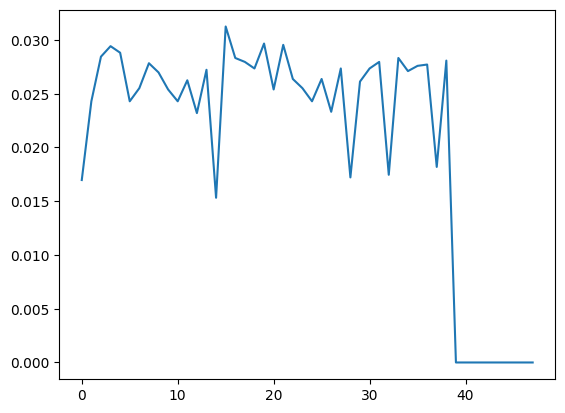

In [11]:
import matplotlib.pyplot as plt
plt.plot(output.attentions[0][0,0,-10,:].float().cpu().numpy())

In [12]:
layers = model.config.num_hidden_layers
heads = model.config.num_attention_heads
vocab = tokenizer.get_vocab()

filtered_ranks = [vocab[v[0]] for v in filtered]
prefix_matching = get_prefix_matching_scores(model, filtered_ranks, layers, heads, num_seeds=num_seeds)

torch.save(prefix_matching, "prefix_matching.pt")

  0%|          | 0/99 [00:00<?, ?it/s]/tmp/ipykernel_2732994/1953945973.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attentions = torch.cat(model(torch.tensor(X).unsqueeze(0).to(model.device),output_attentions=True).attentions)
100%|██████████| 99/99 [1:03:34<00:00, 38.53s/it]


In [15]:

heatmap = go.Heatmap(z=(prefix_matching.mean(dim=0)>0.5).int().cpu().numpy())
fig = go.Figure(data=heatmap)
fig.show()